In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('D:\\projects\\update older projects\\Project\\Predective maintenance\\data\\raw\\ai4i2020.csv')

print(df['Machine failure'].value_counts(normalize=True))



Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [ ]:
# Failure type distribution
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print(df[failure_types].sum())



TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df['Machine failure'].unique()

array([0, 1])

<Axes: xlabel='Machine failure', ylabel='Torque [Nm]'>

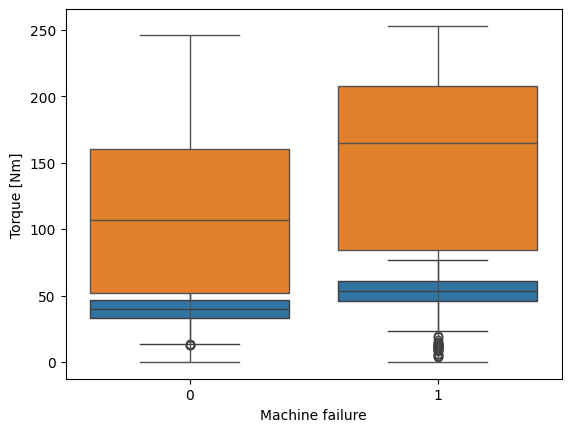

In [ ]:
# Compare distributions failed vs not
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


print(" Basic Info ")
print(df.shape)
print(df.info())
print("\n Target Distribution ")
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True))






=== Basic Info ===
(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64

In [ ]:
# Failure modes
failure_modes = ['TWF','HDF','PWF','OSF','RNF']
print("\nFailure Modes:")
print(df[failure_modes].sum())


Failure Modes:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [ ]:

# Key Statistics
print("\n Numeric Stats ")
print(df.describe())


=== Numeric Stats ===
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800

Text(0.5, 1.0, 'Machine Failure Distribution (Severe Imbalance!)')

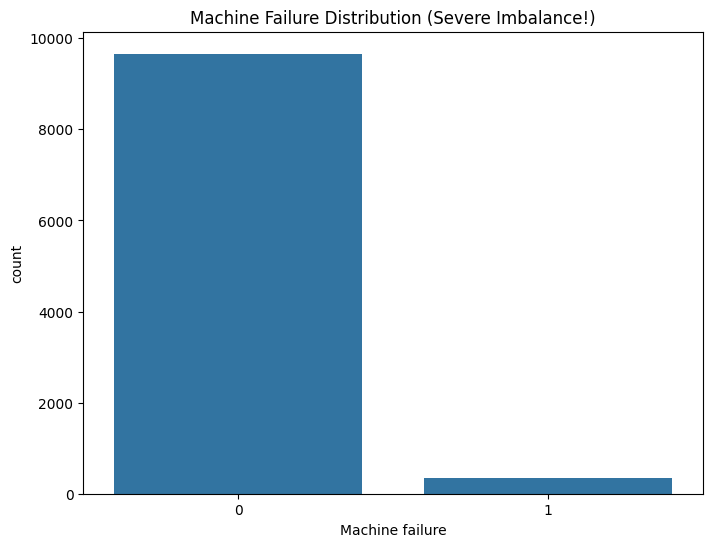

In [ ]:
# Visuals
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Machine failure')
plt.title('Machine Failure Distribution (Severe Imbalance!)')

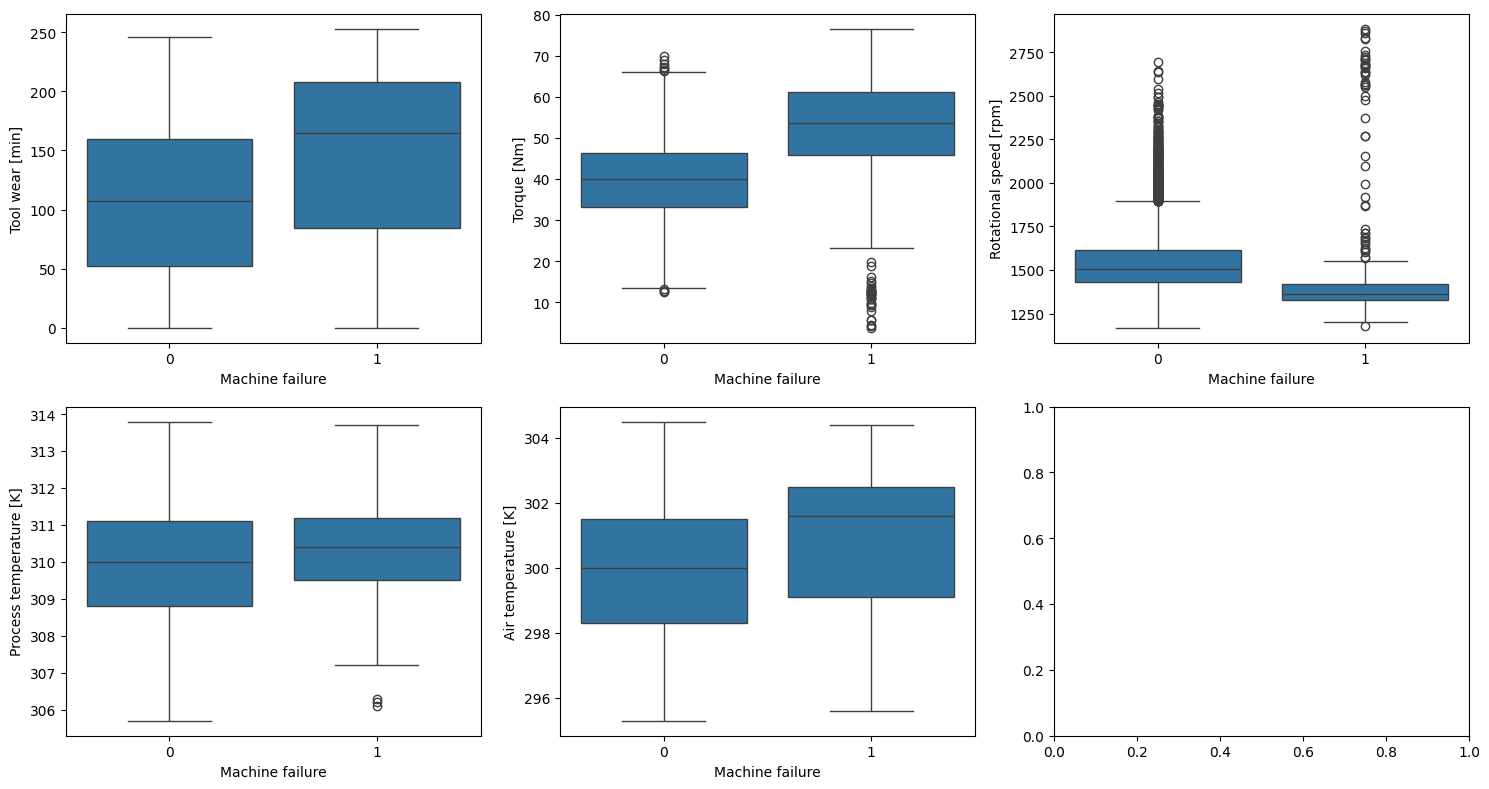

In [ ]:
# Boxplots Most Important
fig, axes = plt.subplots(2, 3, figsize=(15,8))
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df, ax=axes[0,0])
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, ax=axes[0,1])
sns.boxplot(x='Machine failure', y='Rotational speed [rpm]', data=df, ax=axes[0,2])
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df, ax=axes[1,0])
sns.boxplot(x='Machine failure', y='Air temperature [K]', data=df, ax=axes[1,1])
plt.tight_layout()

In [ ]:
# Feature Engineering
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']
df['wear_per_power'] = df['Tool wear [min]'] / (df['power'] + 1)  # avoid div by zero

# Log transform if needed (skewed features)
df['log_tool_wear'] = np.log1p(df['Tool wear [min]'])

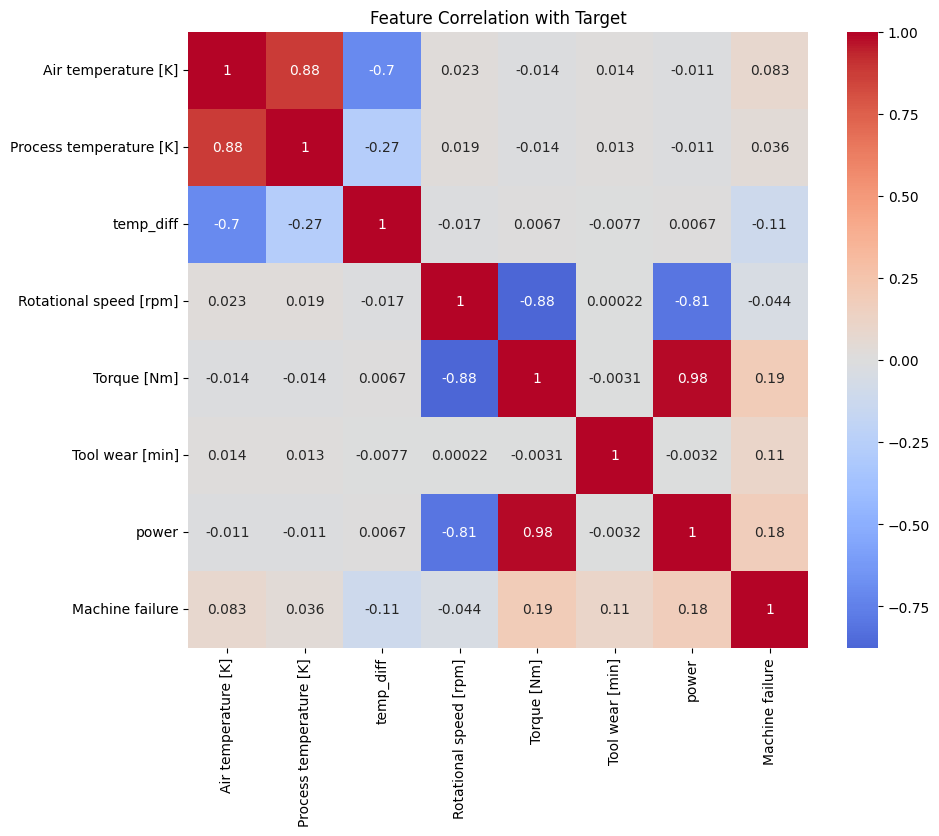

Type
H    0.020937
L    0.039167
M    0.027694
Name: Machine failure, dtype: float64


In [ ]:
import numpy as np

# Correlation heatmap on key features
key_features = ['Air temperature [K]', 'Process temperature [K]', 'temp_diff',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'power', 'Machine failure']

plt.figure(figsize=(10,8))
sns.heatmap(df[key_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Target')
plt.show()

# Failure rate by Product Type
print(df.groupby('Type')['Machine failure'].mean())

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [18]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Use scale_pos_weight for imbalance: ~29 (negative/positive ratio)

In [19]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.force_plot(...)  # for individual predictions

NameError: name 'best_xgb' is not defined